## Half car simulation and application of weight estimation using complex matrix in state-space 


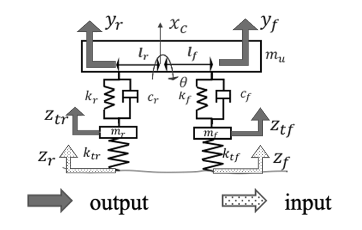

Figure 1

Half-car is build as the figure above. Parameters of the half-car are shown in the table below.

Please refer to `notebooks/sim_config.yaml` for the parameters.

Table 1: Parameters of the half-car
| Parameter | Value | Unit | Variable |
|-----------|-------|-------|-------|
| Mass of the car | 1000 | kg | $mu$ |
| Mass of the front wheel | 113 | kg | $m_f$ |
| Mass of the rear wheel | 90  | kg | $m_r$ |
| Wheel base (distance between front and rear wheels) | 2.5 |  m | $leng$ |
| Center of gravity distance from front wheel | 0.8 | m | $lf$ |
| Front stiffness (normalized) | 54.9  | 1/s2 | $k_f$ |
| Rear stiffness (normalized) | 49.3  | 1/s2 | $k_r$ |
| Front damping (normalized) | 2.910 |  1/s | $c_f$ |
| Rear damping (normalized) | 3.49  | 1/s | $c_r$ |
| Front tire stiffness (normalized) | 576 | 1/s2 | $k_tf$ |
| Rear tire stiffness (normalized) | 519 | 1/s2 | $k_tr$ |
 









### 1. Generate road profile and simulate response

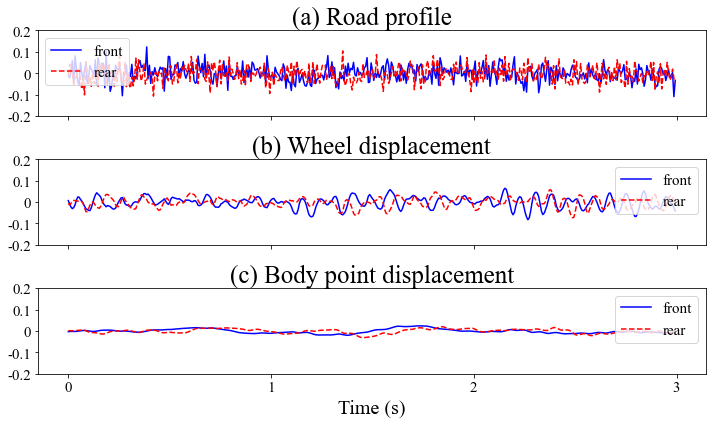

In [1]:
import os
import sys

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
from sim.sim_setup import (
    simulate_response_4dof,
    load_sim_config,
    generate_road_profile,
    compute_natural_frequencies,
)
from plot.plot_results import plot_simulation_results, resample_simulation

# 1. Load config, generate road profile, and simulate responses of vehicle.
# 1.1. Load config
config_path = os.path.join(project_root, "sim", "sim_config.yaml")
config = load_sim_config(config_path)
road_profile = generate_road_profile(config.road, config.vehicle, seed=42)
natural_frequencies = compute_natural_frequencies(config.vehicle)

# 1.2. Run simulation and generate response
vehicle_config = config.vehicle
response_dict = simulate_response_4dof(road_profile, vehicle_config)

# 1.3. Plot after resampling
road_profile, response_dict = resample_simulation(road_profile, response_dict, fs=150)
plot_simulation_results(road_profile, response_dict, Start=2.0, Measurement_Time=3.0)

### 2. Apply Weight Estimation

estimated weight: 0.991 [ton]


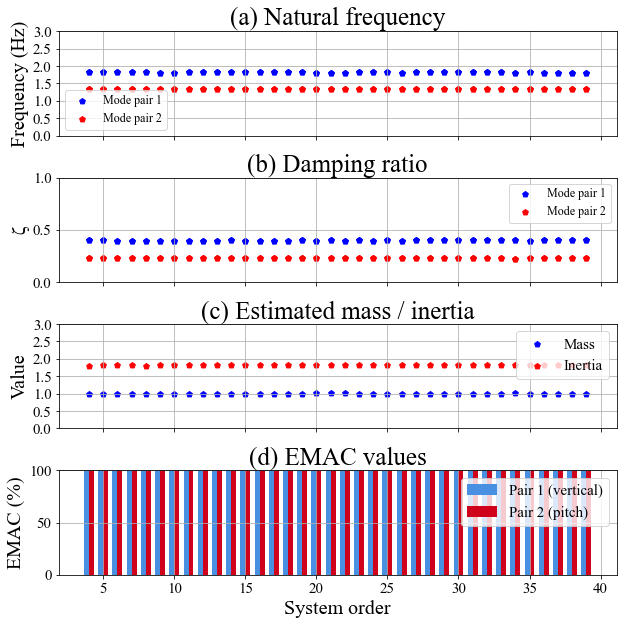

In [2]:
# sys.path.insert(0, project_root)
from estimate_weight import estimate_vehicle_weight

estimation = estimate_vehicle_weight(
    response=response_dict,
    kf=config.vehicle.kf,
    kr=config.vehicle.kr,
    leng=config.vehicle.length,
    fs=150,  # Use the same fs as resampled one
    p=40,  # Hyperparameter for SRIM
    detrend=False,
    plot_figure=True,
)
print(f'estimated weight: {estimation["total_weight"]:.3f} [ton]')